# Decision Boundaries Set up

### Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Import Skitlearn

In [5]:
from sklearn.datasets import make_moons, make_circles , make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
     accuracy_score, confusion_matrix, classification_report
)

### Creation of Synthetic dataset

In [6]:
datasets = {
    "Moons": make_moons(
        n_samples=500,
        noise=0.25,
        random_state=42
    ),
    "Circles": make_circles(
        n_samples=500,
        noise=0.12,
        factor=0.45,
        random_state=42
    ),
    "Linear-ish": make_classification(
        n_samples=500,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        class_sep=1.4,
        random_state=42
    )
}

### Defining models

In [7]:
models={
     "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel="linear", C=1),
    "LinearSVC": LinearSVC(C=1, max_iter=10000),
    "Polynomial SVM": SVC(kernel="poly", degree=3, C=1, gamma="scale"),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale"),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=5,
        random_state=42
    )
}

### Decision Boundary Function

In [8]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, edgecolors="k")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(alpha=0.25)
    plt.show()

### Function for highlightting support vectors fro SVC models

In [9]:
def plot_svm_support_vectors(pipe, X, y, title):
    scaler = pipe.named_steps["scaler"]
    svm_model = pipe.named_steps["model"]

    if not hasattr(svm_model, "support_vectors_"):
        print(f"{title}: This model does not expose support_vectors_.")
        return

    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    decision_scores = pipe.decision_function(grid)
    decision_scores = decision_scores.reshape(xx.shape)

    support_vectors_original = scaler.inverse_transform(
        svm_model.support_vectors_
    )

    plt.figure(figsize=(8, 6))

    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, edgecolors="k")

    plt.contour(
        xx,
        yy,
        decision_scores,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"]
    )

    plt.scatter(
        support_vectors_original[:, 0],
        support_vectors_original[:, 1],
        s=180,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support vectors"
    )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


### Train, Evalute, time and visualise all models


################################################################################
DATASET: Moons
################################################################################

------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------
Train accuracy       : 0.8507
Test accuracy        : 0.8400
Generalization gap   : 0.0107
Training time        : 0.016658 sec
Prediction time      : 0.001545 sec
Confusion matrix:
[[54  9]
 [11 51]]


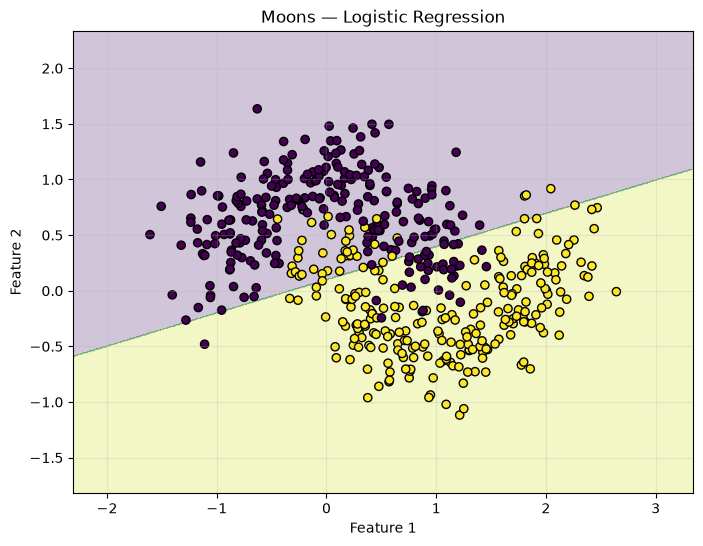


------------------------------------------------------------
Model: Linear SVM
------------------------------------------------------------
Train accuracy       : 0.8613
Test accuracy        : 0.8240
Generalization gap   : 0.0373
Training time        : 0.007996 sec
Prediction time      : 0.024521 sec
Confusion matrix:
[[54  9]
 [13 49]]


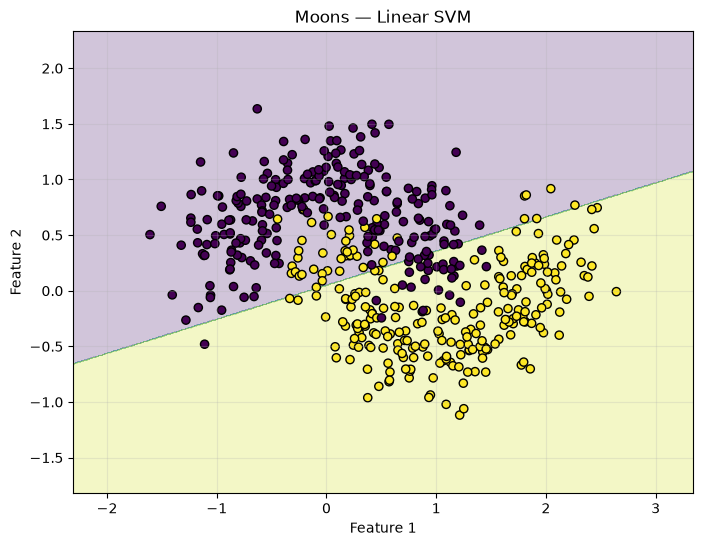

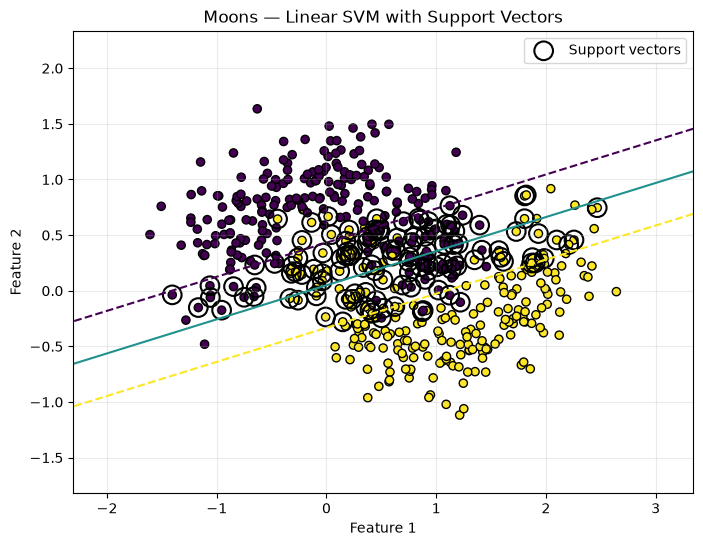


------------------------------------------------------------
Model: LinearSVC
------------------------------------------------------------
Train accuracy       : 0.8507
Test accuracy        : 0.8400
Generalization gap   : 0.0107
Training time        : 0.004991 sec
Prediction time      : 0.000579 sec
Confusion matrix:
[[54  9]
 [11 51]]


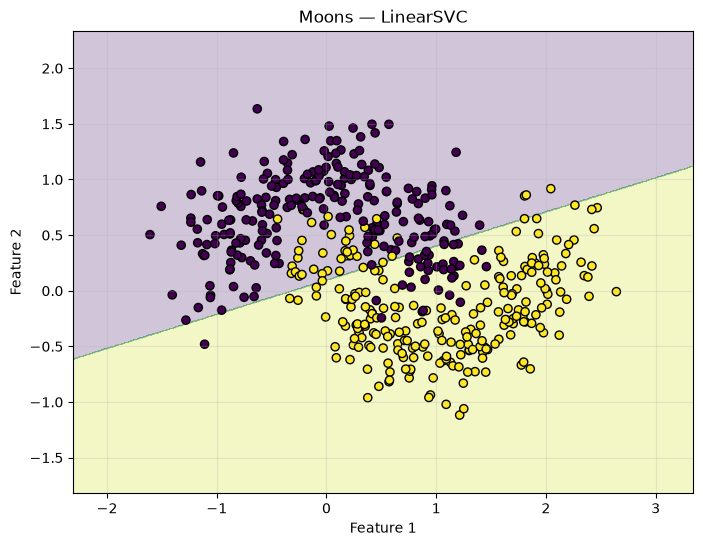


------------------------------------------------------------
Model: Polynomial SVM
------------------------------------------------------------
Train accuracy       : 0.8453
Test accuracy        : 0.8320
Generalization gap   : 0.0133
Training time        : 0.005772 sec
Prediction time      : 0.000881 sec
Confusion matrix:
[[53 10]
 [11 51]]


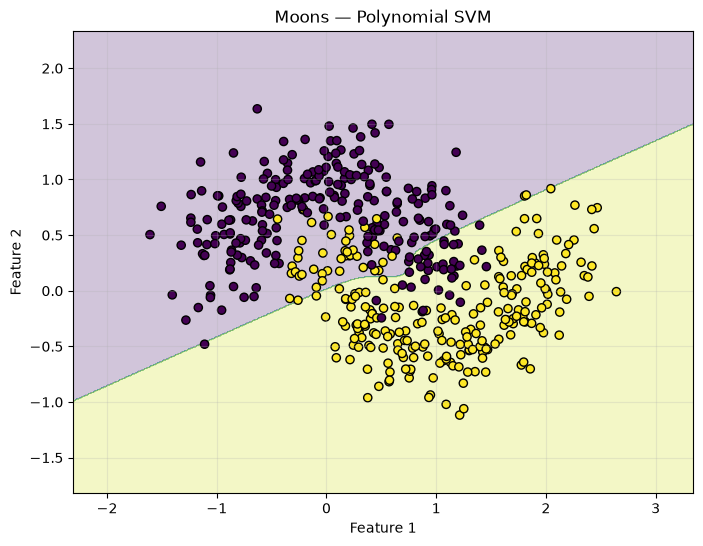

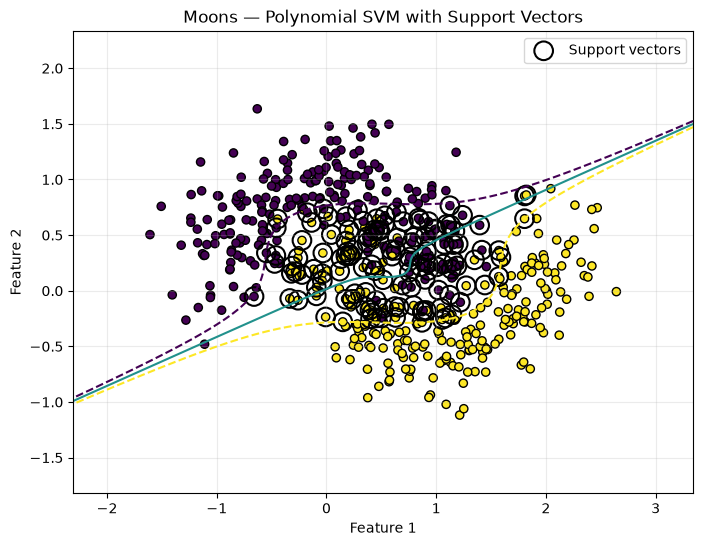


------------------------------------------------------------
Model: RBF SVM
------------------------------------------------------------
Train accuracy       : 0.9440
Test accuracy        : 0.9440
Generalization gap   : 0.0000
Training time        : 0.006860 sec
Prediction time      : 0.001802 sec
Confusion matrix:
[[61  2]
 [ 5 57]]


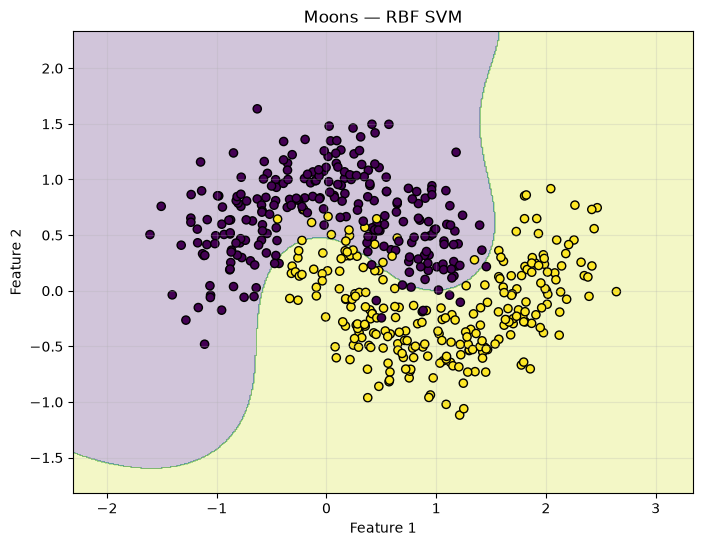

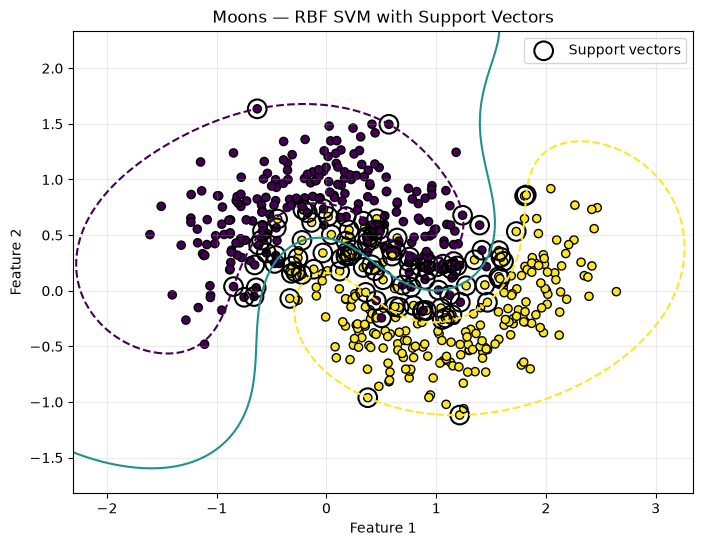


------------------------------------------------------------
Model: KNN
------------------------------------------------------------
Train accuracy       : 0.9573
Test accuracy        : 0.9280
Generalization gap   : 0.0293
Training time        : 0.020858 sec
Prediction time      : 0.006948 sec
Confusion matrix:
[[59  4]
 [ 5 57]]


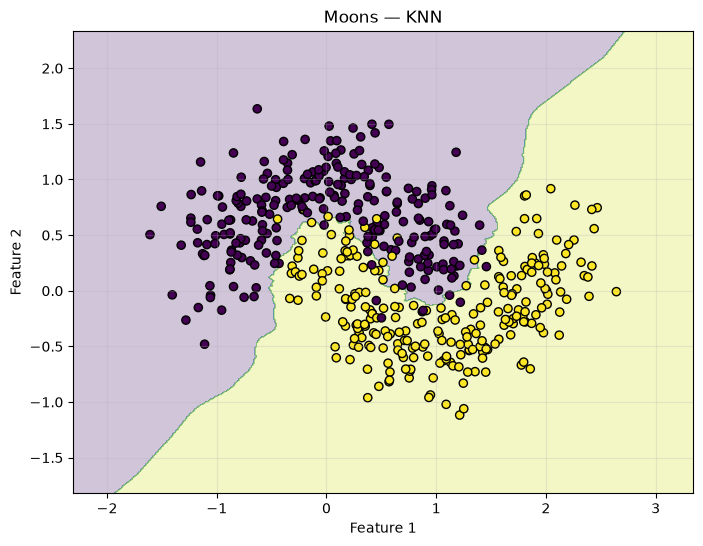


------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------
Train accuracy       : 0.9653
Test accuracy        : 0.9520
Generalization gap   : 0.0133
Training time        : 0.336025 sec
Prediction time      : 0.018453 sec
Confusion matrix:
[[62  1]
 [ 5 57]]


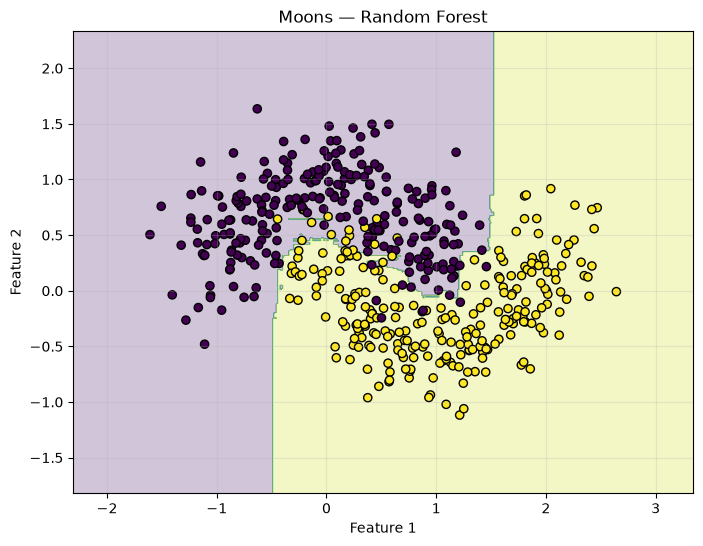


################################################################################
DATASET: Circles
################################################################################

------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------
Train accuracy       : 0.5333
Test accuracy        : 0.4800
Generalization gap   : 0.0533
Training time        : 0.006097 sec
Prediction time      : 0.000910 sec
Confusion matrix:
[[25 38]
 [27 35]]


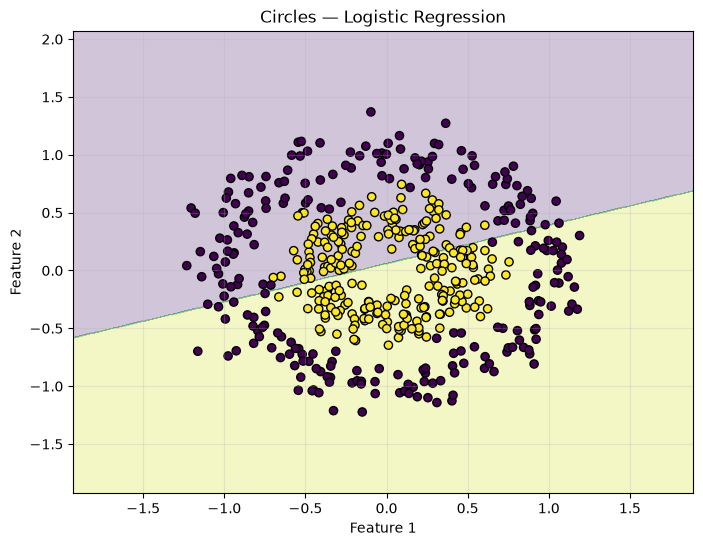


------------------------------------------------------------
Model: Linear SVM
------------------------------------------------------------
Train accuracy       : 0.6027
Test accuracy        : 0.5440
Generalization gap   : 0.0587
Training time        : 0.007989 sec
Prediction time      : 0.001783 sec
Confusion matrix:
[[18 45]
 [12 50]]


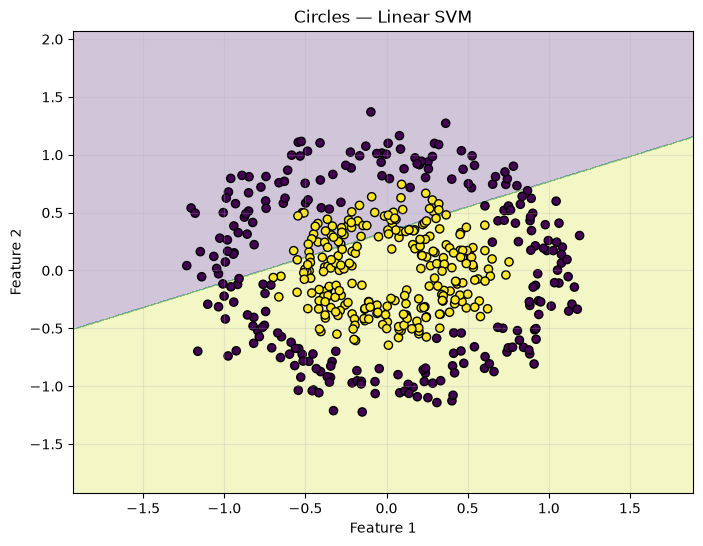

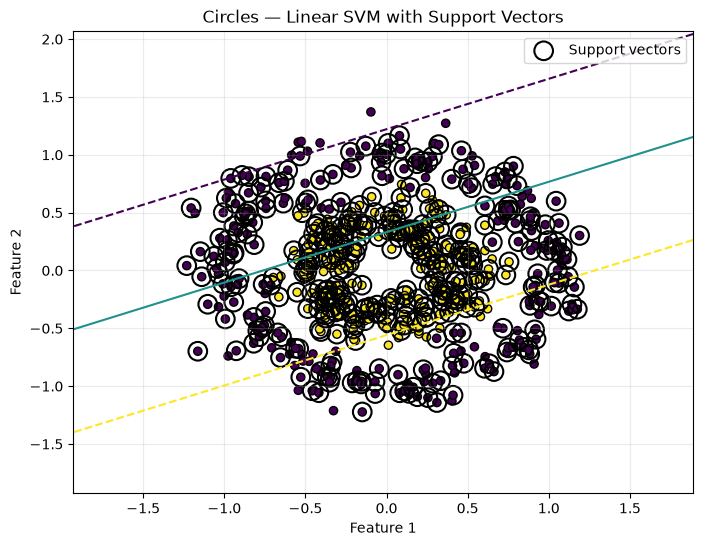


------------------------------------------------------------
Model: LinearSVC
------------------------------------------------------------
Train accuracy       : 0.5333
Test accuracy        : 0.4800
Generalization gap   : 0.0533
Training time        : 0.004792 sec
Prediction time      : 0.000608 sec
Confusion matrix:
[[25 38]
 [27 35]]


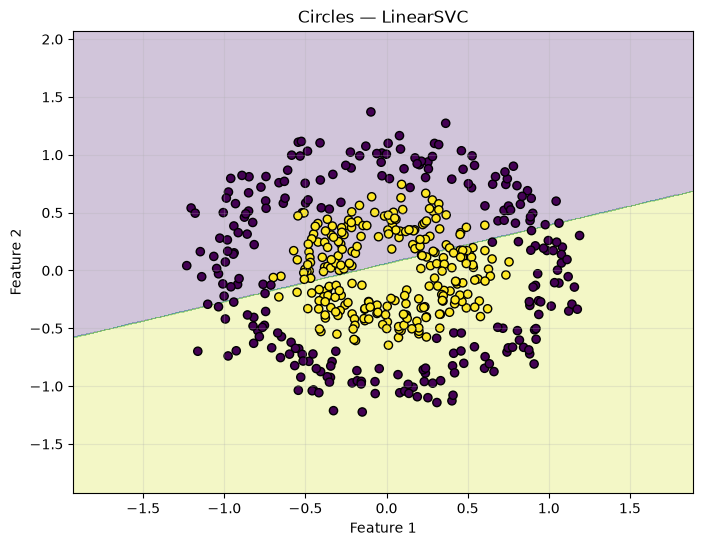


------------------------------------------------------------
Model: Polynomial SVM
------------------------------------------------------------
Train accuracy       : 0.6720
Test accuracy        : 0.6240
Generalization gap   : 0.0480
Training time        : 0.008634 sec
Prediction time      : 0.002140 sec
Confusion matrix:
[[16 47]
 [ 0 62]]


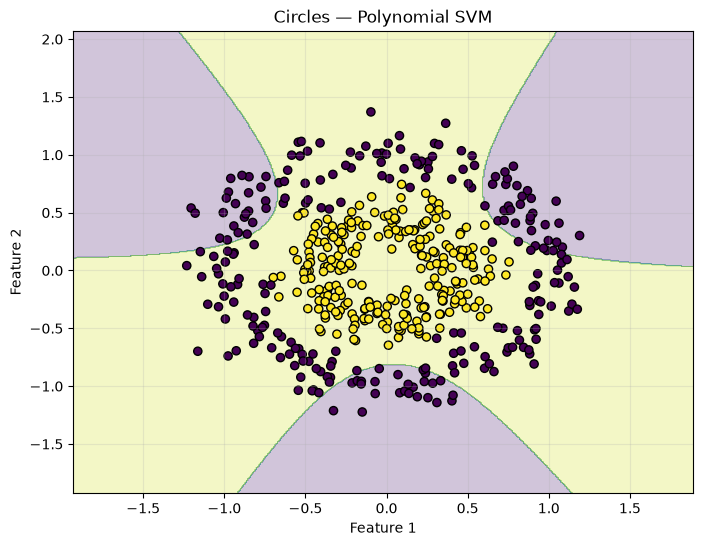

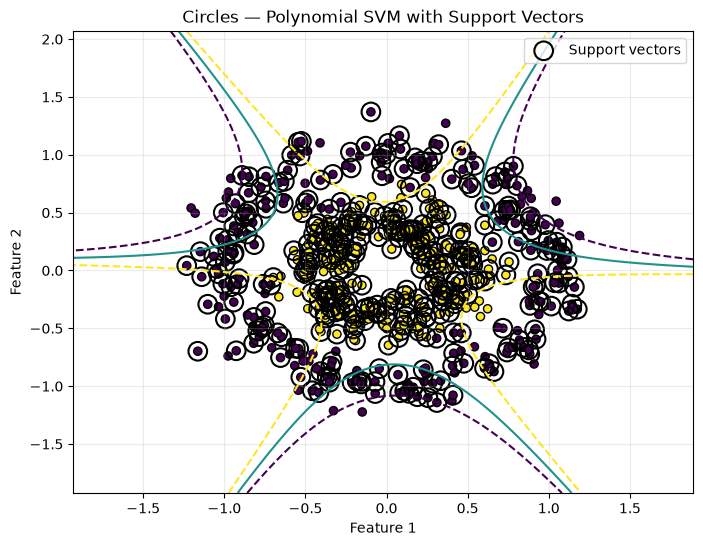


------------------------------------------------------------
Model: RBF SVM
------------------------------------------------------------
Train accuracy       : 0.9787
Test accuracy        : 0.9680
Generalization gap   : 0.0107
Training time        : 0.005391 sec
Prediction time      : 0.001287 sec
Confusion matrix:
[[62  1]
 [ 3 59]]


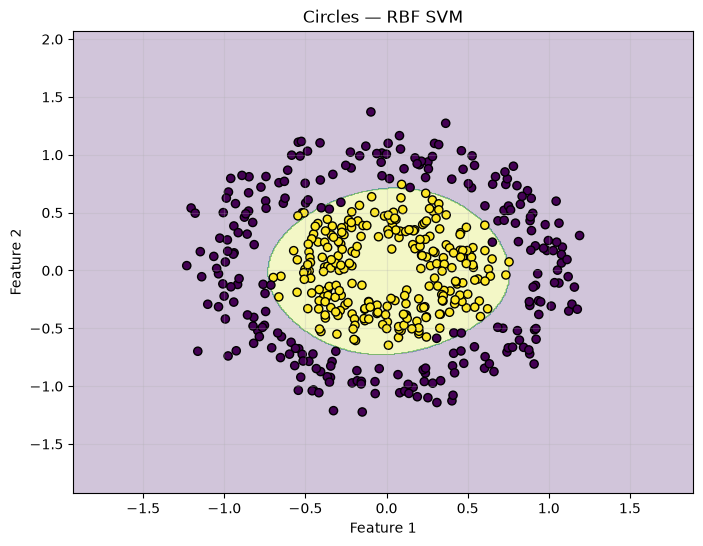

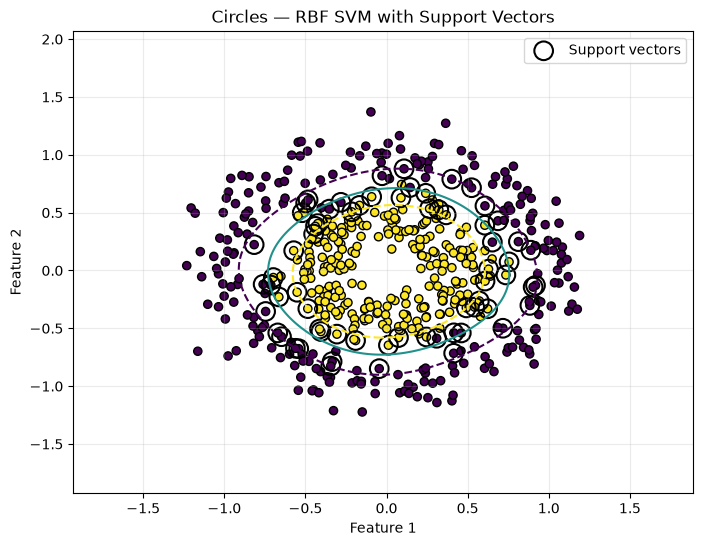


------------------------------------------------------------
Model: KNN
------------------------------------------------------------
Train accuracy       : 0.9893
Test accuracy        : 0.9680
Generalization gap   : 0.0213
Training time        : 0.005635 sec
Prediction time      : 0.003586 sec
Confusion matrix:
[[62  1]
 [ 3 59]]


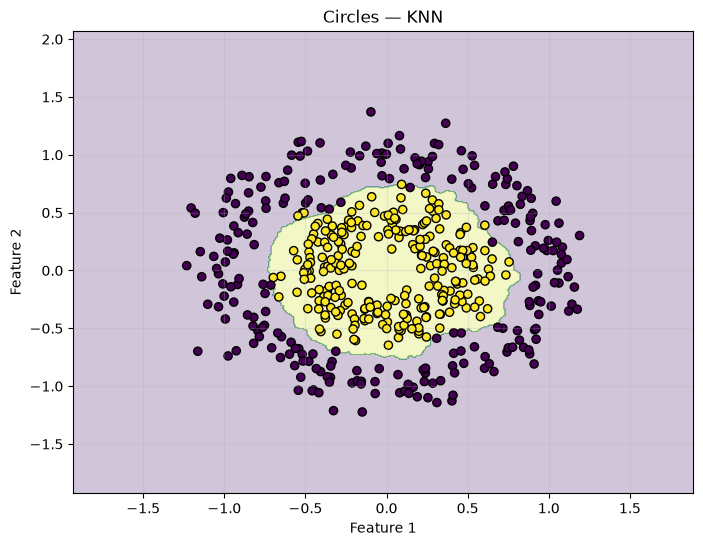


------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------
Train accuracy       : 0.9893
Test accuracy        : 0.9760
Generalization gap   : 0.0133
Training time        : 0.405325 sec
Prediction time      : 0.017936 sec
Confusion matrix:
[[63  0]
 [ 3 59]]


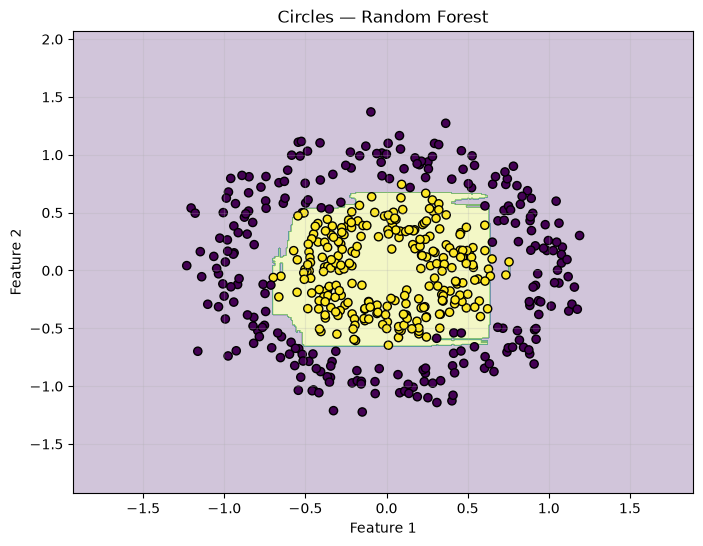


################################################################################
DATASET: Linear-ish
################################################################################

------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------
Train accuracy       : 0.9280
Test accuracy        : 0.9760
Generalization gap   : -0.0480
Training time        : 0.009433 sec
Prediction time      : 0.000699 sec
Confusion matrix:
[[59  3]
 [ 0 63]]


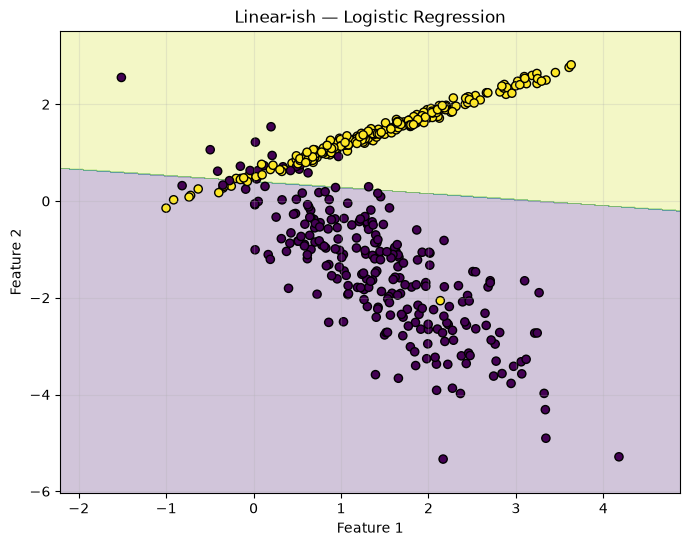


------------------------------------------------------------
Model: Linear SVM
------------------------------------------------------------
Train accuracy       : 0.9467
Test accuracy        : 0.9600
Generalization gap   : -0.0133
Training time        : 0.007378 sec
Prediction time      : 0.001465 sec
Confusion matrix:
[[57  5]
 [ 0 63]]


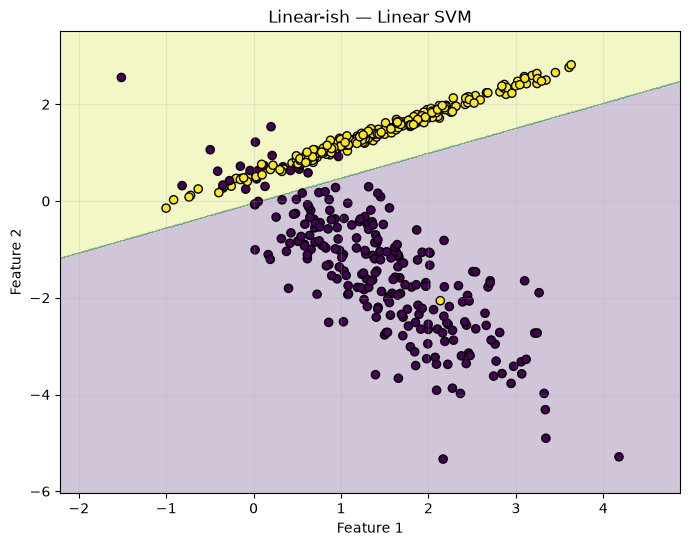

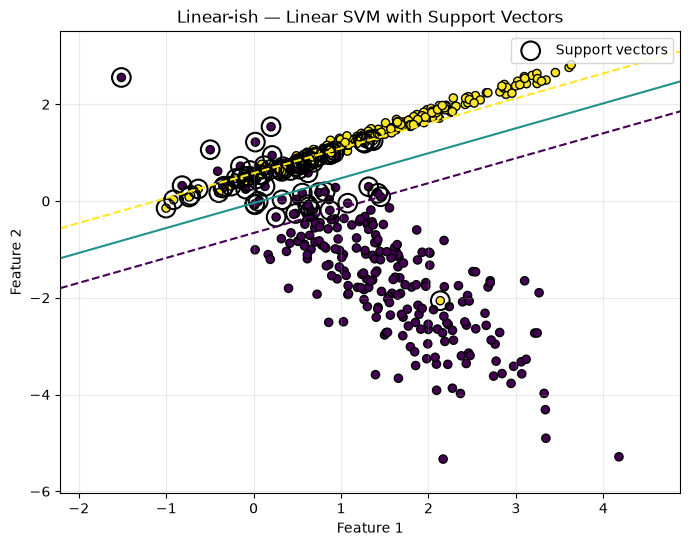


------------------------------------------------------------
Model: LinearSVC
------------------------------------------------------------
Train accuracy       : 0.9280
Test accuracy        : 0.9760
Generalization gap   : -0.0480
Training time        : 0.005046 sec
Prediction time      : 0.001099 sec
Confusion matrix:
[[59  3]
 [ 0 63]]


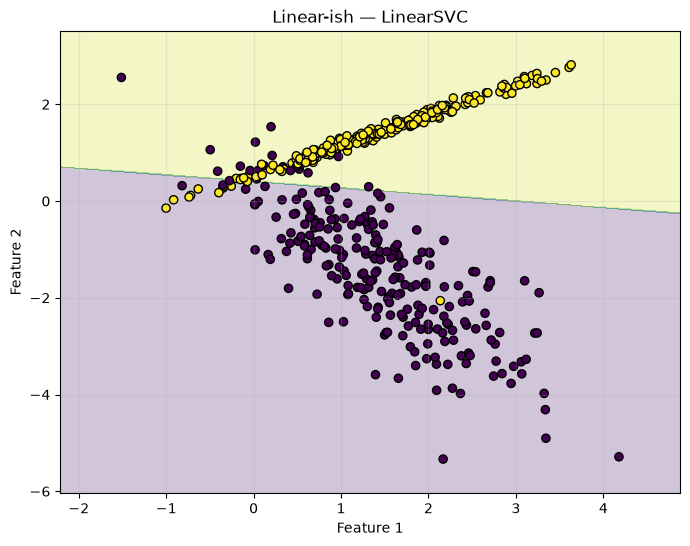


------------------------------------------------------------
Model: Polynomial SVM
------------------------------------------------------------
Train accuracy       : 0.9387
Test accuracy        : 0.9600
Generalization gap   : -0.0213
Training time        : 0.007875 sec
Prediction time      : 0.001651 sec
Confusion matrix:
[[57  5]
 [ 0 63]]


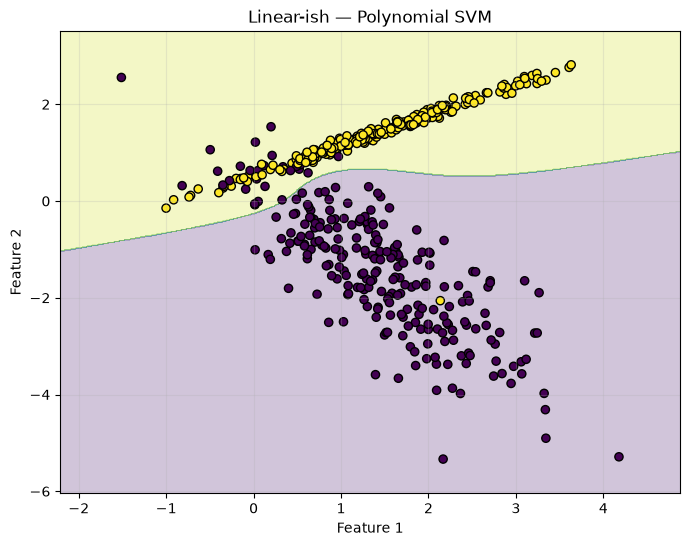

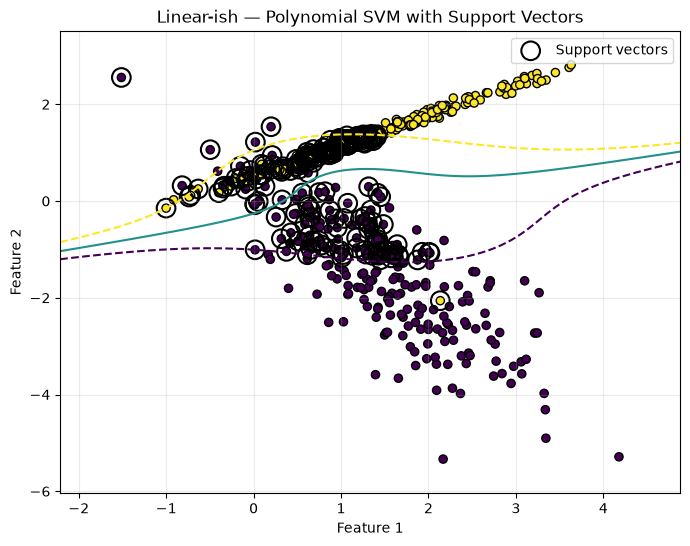


------------------------------------------------------------
Model: RBF SVM
------------------------------------------------------------
Train accuracy       : 0.9440
Test accuracy        : 0.9600
Generalization gap   : -0.0160
Training time        : 0.007764 sec
Prediction time      : 0.001969 sec
Confusion matrix:
[[57  5]
 [ 0 63]]


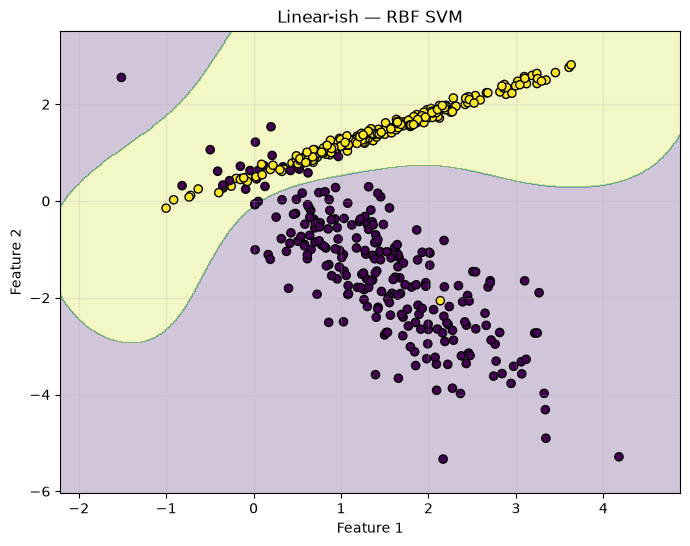

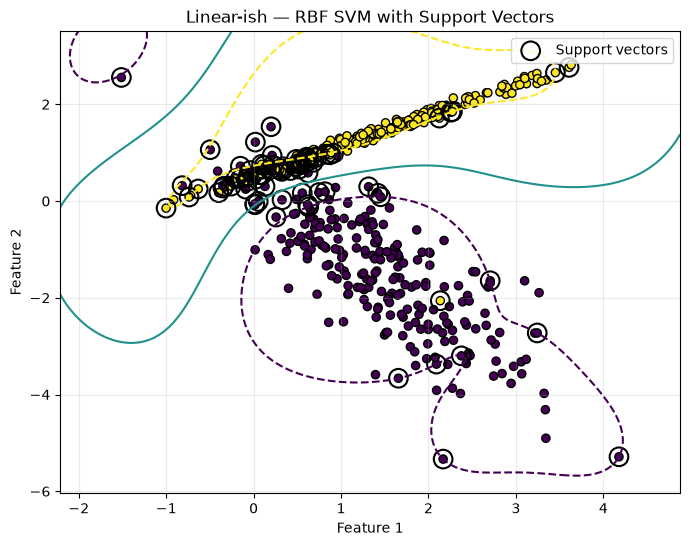


------------------------------------------------------------
Model: KNN
------------------------------------------------------------
Train accuracy       : 0.9600
Test accuracy        : 0.9520
Generalization gap   : 0.0080
Training time        : 0.005375 sec
Prediction time      : 0.002947 sec
Confusion matrix:
[[57  5]
 [ 1 62]]


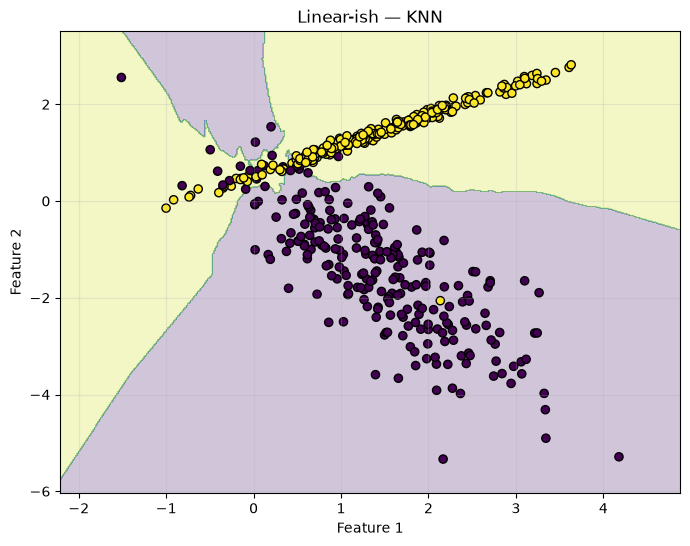


------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------
Train accuracy       : 0.9973
Test accuracy        : 0.9600
Generalization gap   : 0.0373
Training time        : 0.331811 sec
Prediction time      : 0.020135 sec
Confusion matrix:
[[57  5]
 [ 0 63]]


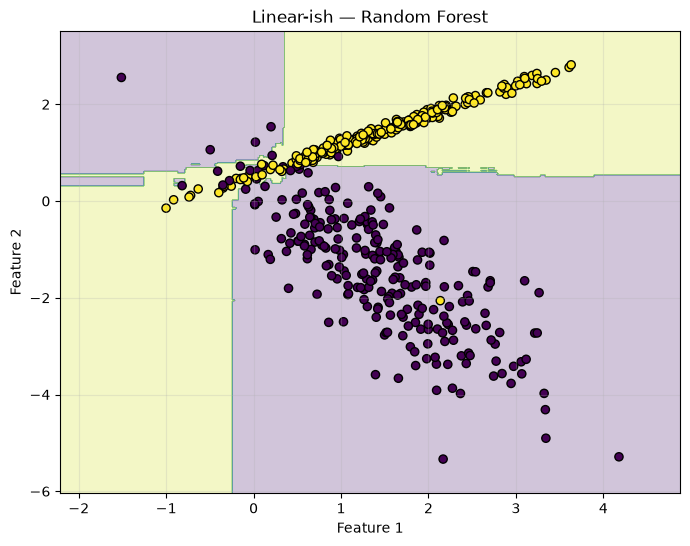


Final comparison table:


,dataset,model,train_accuracy,test_accuracy,generalization_gap,training_time_sec,prediction_time_sec
13,Circles,Random Forest,0.989333,0.976,0.013333,0.405325,0.017936
11,Circles,RBF SVM,0.978667,0.968,0.010667,0.005391,0.001287
12,Circles,KNN,0.989333,0.968,0.021333,0.005635,0.003586
10,Circles,Polynomial SVM,0.672000,0.624,0.048000,0.008634,0.002140
8,Circles,Linear SVM,0.602667,0.544,0.058667,0.007989,0.001783
7,Circles,Logistic Regression,0.533333,0.480,0.053333,0.006097,0.000910
9,Circles,LinearSVC,0.533333,0.480,0.053333,0.004792,0.000608
14,Linear-ish,Logistic Regression,0.928000,0.976,-0.048000,0.009433,0.000699
16,Linear-ish,LinearSVC,0.928000,0.976,-0.048000,0.005046,0.001099
15,Linear-ish,Linear SVM,0.946667,0.960,-0.013333,0.007378,0.001465


In [10]:
import time
all_results = []

for dataset_name, (X, y) in datasets.items():
    print("\n" + "#" * 80)
    print(f"DATASET: {dataset_name}")
    print("#" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

    for model_name, model in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        start_time = time.time()
        pipe.fit(X_train, y_train)
        training_time = time.time() - start_time

        start_time = time.time()
        y_test_pred = pipe.predict(X_test)
        prediction_time = time.time() - start_time

        y_train_pred = pipe.predict(X_train)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        gap = train_acc - test_acc

        all_results.append({
            "dataset": dataset_name,
            "model": model_name,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "generalization_gap": gap,
            "training_time_sec": training_time,
            "prediction_time_sec": prediction_time
        })
        print("\n" + "-" * 60)
        print(f"Model: {model_name}")
        print("-" * 60)
        print(f"Train accuracy       : {train_acc:.4f}")
        print(f"Test accuracy        : {test_acc:.4f}")
        print(f"Generalization gap   : {gap:.4f}")
        print(f"Training time        : {training_time:.6f} sec")
        print(f"Prediction time      : {prediction_time:.6f} sec")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_test_pred))

        plot_decision_boundary(
            pipe,
            X,
            y,
            title=f"{dataset_name} — {model_name}"
        )

        if model_name in ["Linear SVM", "Polynomial SVM", "RBF SVM"]:
            plot_svm_support_vectors(
                pipe,
                X,
                y,
                title=f"{dataset_name} — {model_name} with Support Vectors"
            )

results_df = pd.DataFrame(all_results)

print("\nFinal comparison table:")
display(results_df.sort_values(
    by=["dataset", "test_accuracy"],
    ascending=[True, False]
))